<div id="bg-slide">
    <center>
    <h1>DFT introduction #2</h1>
<center>
<br>
<table>
  <tr>
      <td><p><h1>Team Rutgers</h1></p><p><h2>(Michele, Ezekiel & Valeria)</h2></p><p><h2>Rutgers University-Newark</h2></p></td> 
      <td><img src="../figures/logos/ASESMA_logo.png" width=300 height=300 /></td>
  </tr>
  <tr>
    <td></td>
    <td> https://prg.rutgers.edu</td>
  </tr>
</table>
<br>
<h3>Retrieve this presentation at:</h3>
<br>
<center>https://github.com/Quantum-MultiScale-Template/DFT-Intro/2025/ASESMA/miniASESMA_DFT_2.ipynb</center>

<br>

<center><h3> mini ASESMA 2026 -- Accra, Ghana -- June 15, 2026</h3></center>
</div>


# Goal of this lecture
 - Understand what basis sets are
 - Introduce basics about basis sets (PWs and local orbitals like GTOs)
 - Discretize the KS equations so they can be solved by a computer
 - Focus on PW (GTOs done on your own, numerical orbitals introduced by Javier later)

# Split into `N` groups

 - Assign number `1-N` to each student
 - Groups sit together
 - Possibly have 1 instructor per group

In [4]:
from IPython.display import IFrame
import numpy as np
import matplotlib.pyplot as plt
from ase.build import molecule
from pyscf import gto

# My assumptions

 - Basic linear algebra (vectors, matrices, operators, wavefunctions)
 - Undergraduate QM
 - Dirac notation (i.e., i-th vector $\to |i\rangle$ or $|\psi_i\rangle$, scalar product between <i>i</i> and <i>j</i> $\to \langle \psi_i | \psi_j\rangle$)
 - Kohn-Sham equations

# Why are basis sets needed?

 - They provide a representation
 - Allow us to discretize the problem

# Let's expand a function in a basis

$$
\psi_k(r) = \sum_i C_{ik} \chi_i(r)
$$

 - $\{\chi_i(r)\}$ are basis functions forming a <b>basis set</b>
 - $\{C_{ik}\}$ are expansion coefficients, $C_{ik}\in \mathbb{C}$

# Examples of basis sets

 - Plane waves (PW)
$$
 \chi_{G}(r) = \frac{1}{\sqrt{\Omega}} e^{iGr}
$$

 - Gaussian-Type Orbitals (GTOs)
 $$
 \chi_{\mu,\alpha}(r) = \left(\frac{2\alpha}{\pi}\right)^{d/2} e^{-\alpha |r-\mu|^2}
 $$

 - Numerical Orbitals (Javier will introduce later this week)
 - ...

# What do they look like? Let's use `Python`

In [24]:
L=10; X = np.linspace(start=0,stop=L,num=1000,endpoint=False)
def pw(x,G):
    return 1.0/np.sqrt(L)*np.exp(1j*2*np.pi*G*x)
def gto(x,center,alpha):
    return np.sqrt(alpha/np.pi)*np.exp(-alpha*(x-center)**2)

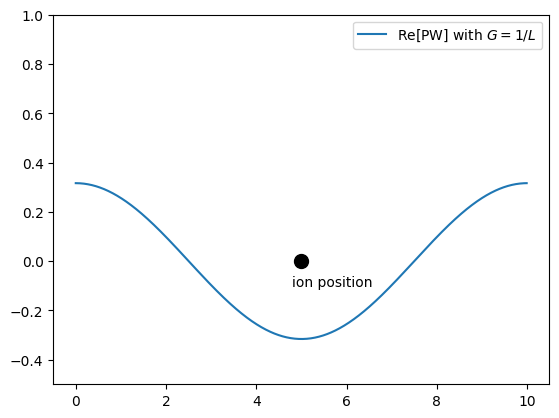

In [27]:
fig = plt.figure()#(figsize=(8,5))
plt.plot(X,np.real(pw(X,G=1/L)), label=r"Re[PW] with $G=1/L$")
#plt.plot(X,np.imag(pw(X,G=1)), label=r"Im[PW] with $G=1$")
#plt.plot(X,gto(X,center=5,alpha=1),label=r"GTO centered in $x=5$, with $\alpha=1$")
plt.plot(5, 0, 'ko', markersize=10); plt.text(x=4.8,y=-0.1,s="ion position")
plt.ylim([-.5,1]); plt.legend()

# Challenge 1
 - Are GTOs an orthonormal basis set? Justify.
 - Are PWs an orthonormal basis set? Justify.
 
 The condition for orthonormality $S_{ij}=\langle \chi_i | \chi_j\rangle = \delta_{ij}$.
 
 <center><img src="../figures/random/qr_poll2.1.png" width=500 height=300 /></center>
 

# How many plane waves are needed?

 - You will attack this question in your Homework `miniASESMA_DFT_2_Homework_1.ipynb`
 - The homework will introduce the `PW cutoff` needed by most PW codes, like QE
 - For <span style="color: red;">QE</span>py, you will see something like (all values in Ry):

In [1]:
qe_options = {}
qe_options["&electrons"] = {}
qe_options["&electrons"]["ecutwf"] = 80
qe_options["&electrons"]["ecutrho"] = 320

- `ecutwf` is the kinetic energy of the PW with the largest $G$ point
- `ecutrho` is the kinetic energy of the PW with the largest $G$ point used to Fourier transform the electron density $n(r)$. 
 - Let me know during the break if you wish to know why these two cutoffs are different.

# How do basis sets "discretize" the KS equations?

<br>
Working with your group mates, discretize the KS equations 
$$-\frac{1}{2}\nabla^2 \phi_k(r) + v_s(r) \phi_k(r) = \varepsilon_k \phi_k(r)$$

<div class="alert alert-success"> 
        Use: $\{\chi_i(r)\}$ such that $\psi_k(r) = \sum_i C_{ik} \chi_i(r)$ 
</div>

<div class="alert alert-success"> 
        Consider: KS Hamiltonian matrix elements are $H_{ij}=\langle \chi_i | \hat H | \chi_j \rangle$ and the overlap elements among the basis functions are $S_{ij}=\langle \chi_i|\chi_j\rangle$.
</div>

# Discretized KS equations

The final result should be 

$$
\sum_i H_{ji}C_{ik} = \varepsilon_k \sum_i S_{ji} C_{ik}
$$ 

or in matrix form

<div style="font-size: 170%;">
$$
\color{green}{\mathbb{HC}=\mathbb{SC\varepsilon}}
$$
</div>



 - $\mathbb{H}$: The KS Hamiltonian, mean field Hamiltonian or Fock matrix
 - $\mathbb{C}$: The matrix of the coefficients. Each column represents a KS orbital. In PW, these are simply the `bands`
 - $\varepsilon$: A diagonal matrix with the orbital energies, $\varepsilon_k$. Also KS eigenvalues, ...
 - $\mathbb{S}$: Overlap matrix. Diagonal in PW.

# Matrix elements of the kinetic energy operator, needed to solve $\mathbb{HC=SC\varepsilon}$

$$
\langle \chi_i | \hat T | \chi_j \rangle = -\frac{1}{2\Omega} \int dr ~ (-G_j^2) ~ e^{i(G_j-G_i)}r = \mathbf{\color{red}{\frac{G_j^2}{2}\delta_{ij}}}
$$

<center> <div class="alert alert-success"> <b>It's diagonal! ... and cheap to compute ...</b></div></center>

# Matrix elements of $v_s(r)$, needed to solve $\mathbb{HC=SC\varepsilon}$

$$
\langle \chi_i | v_s | \chi_j\rangle = \frac{1}{\Omega}\int dr v_s(r) e^{i(G_j-G_i)r} 
$$

<center>
    <div class="alert alert-danger">
        <b>Not a diagonal matrix</b>
    </div>
</center>

But... we can use the $G$ components of $\tilde v_s(G)$:
$$
\langle \chi_i | v_s | \chi_j\rangle = \frac{1}{\Omega}\tilde v_s(G_i-G_j)
$$
which gives the matrix elements of $v_s$ <b>almost</b> directly.

# Hartree potential, the most difficult piece of $v_s(r)$

$$
v_H(r) = \int dr' \frac{n(r')}{|r-r'|} \equiv \color{red}{n \star \frac{1}{|r|}}
$$

<center>
    <div class="alert alert-success">
        Let's use the <a href="https://en.wikipedia.org/wiki/Convolution_theorem">convolution theorem</a>: $f = h \star g \to \tilde f = \tilde h \cdot \tilde g$
    </div>
</center>

$$
\tilde v_H(G) = \tilde n(G) \frac{4\pi}{G^2} \to \langle \chi_i | v_H | \chi_j\rangle = \frac{1}{\Omega} \tilde v_H(G_2-G_1)
$$

<center>
    <div class="alert alert-success">
        <b>Thanks to Fast Fourier Transforms (FFT), the potential is computed with a $\mathcal{O}(N\ln N)$ number of operations!
    </div>
</center>

# Challenge 2
 
 - Can you derive the equations we just presented?
  
 <center><img src="../figures/random/qr_poll2.2.png" width=500 height=300 /></center>
 

# Now we can solve  $\mathbb{HC=C\varepsilon}$?

$$
H_{ij} =  \left[ \frac{G_i^2}{2} \delta_{ij} + \frac{1}{\Omega}\tilde v_s(G_j - G_i) \right] \\ 
\text{ ... and ... } S_{ij} = \delta_{ij}
$$

Remember $v_s(r) = v_{eN}(r) + v_H(r) + v_{xc}(r)$.

<div class="alert alert-warning">
    <h4>Is it enough? </h4>
</div>

<div class="alert alert-warning">
    <h4>How do we recover the electron density, $n(r)$?</h4>
</div>

<center><div class="alert alert-success">
    <h4>After the break!</h4>
</div></center>

# ... we note: PWs are not perfect ...

- Need many PWs to represent "spiky" or highly oscillatory features ($v_{eN}(r)$, $n(r)$ in the ion core region)
- Thus, **pseudopotentials** are typically employed to
    1) avoid the *Coulomb singularity* of the electron-nuclear interaction potential
    2) avoid *core of atoms* (spiky/oscillatory density and orbitals, more from Javier tomorrow!)

# Why are PW basis so useful?

 - Orthonormal! 

 - Systematically improvable: higher $N$ (or equivalently $\max\left[ G \right]$) leads to better results. 

 - Evaluation of the kinetic energy operator and solution of the Poisson equation are <b> easy, with $\mathcal{O}(N\ln N)$ complexity</b>

<center><div class="alert alert-success">
    <h4>Break time!</h4>
</div></center>